## AuxTel Mount fails - 11-Mar-21

In this notebook, investigate mount in position error from 10-Mar-21

In [1]:
import sys, time, os, asyncio

from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.time import Time, TimeDelta
from lsst_efd_client import EfdClient


In [2]:
# Get EFD client and bring in Lupton's unpacking code
client = EfdClient('summit_efd')

def merge_packed_time_series(packed_dataframe, base_field, stride=1, 
                             ref_timestamp_col="cRIO_timestamp", internal_time_scale="tai"):
    """Select fields that are time samples and unpack them into a dataframe.
            Parameters
            ----------
            packedDF : `pandas.DataFrame`
                packed data frame containing the desired data
            base_field :  `str`
                Base field name that will be expanded to query all
                vector entries.
            stride : `int`, optional
                Only use every stride value when unpacking.  Must be a factor
                of the number of packed values.
                (1 by default)
            ref_timestamp_col : `str`, optional
                Name of the field name to use to assign timestamps to unpacked
                vector fields (default is 'cRIO_timestamp').
            internal_time_scale : `str`, optional
                Time scale to use when converting times to internal formats
                ('tai' by default). Equivalent to EfdClient.internal_scale
        Returns
            -------
            result : `pandas.DataFrame`
                A `pandas.DataFrame` containing the results of the query.
            """
    
    packed_fields = [k for k in packed_dataframe.keys() if k.startswith(base_field)]
    packed_fields = sorted(packed_fields, key=lambda k: int(k[len(base_field):]))  # sort by pack ID
    npack = len(packed_fields)
    if npack%stride != 0:
        raise RuntimeError(f"Stride must be a factor of the number of packed fields: {stride} v. {npack}")
    packed_len = len(packed_dataframe)
    n_used = npack//stride   # number of raw fields being used
    output = np.empty(n_used*packed_len)
    times = np.empty_like(output, dtype=packed_dataframe[ref_timestamp_col][0])
    
    if packed_len == 1:
        dt = 0
    else:
        dt = (packed_dataframe[ref_timestamp_col][1] - packed_dataframe[ref_timestamp_col][0])/npack
    for i in range(0, npack, stride):
        i0 = i//stride
        output[i0::n_used] = packed_dataframe[f"{base_field}{i}"]
        times[i0::n_used] = packed_dataframe[ref_timestamp_col] + i*dt
     
    timestamps = Time(times, format='unix', scale=internal_time_scale).datetime64
    return pd.DataFrame({base_field:output, "times":times}, index=timestamps)

In [3]:
# These are for finding the timestamps of the events
start = Time('2021-03-10T21:00:00') #this is UTC
end = Time('2021-03-11T01:00:00')
timestamp = f"time >= '{start}+00:00' AND time <= '{end}+00:00'"

In [4]:
# Azimuth data as a timebase
mount_position = await client.select_time_series("lsst.sal.ATMCS.mount_AzEl_Encoders", ['*'],
                                          start, end)
az = merge_packed_time_series(mount_position, 'azimuthCalculatedAngle', stride=100)

In [47]:
# All axes in position events
query = f'SELECT "inPosition" FROM "efd"."autogen"."lsst.sal.ATMCS.logevent_allAxesInPosition" \
WHERE {timestamp} and inPosition = true'

inPosition = await client.influx_client.query(query)
print(start, end)
print(len(inPosition))
print(inPosition)

2021-03-10T21:00:00.000 2021-03-11T01:00:00.000
18
                                  inPosition
2021-03-10 21:06:11.425000+00:00        True
2021-03-10 21:14:48.424000+00:00        True
2021-03-10 21:15:07.028000+00:00        True
2021-03-10 21:16:11.320000+00:00        True
2021-03-10 21:16:43.170000+00:00        True
2021-03-10 21:25:43.823000+00:00        True
2021-03-10 21:29:04.172000+00:00        True
2021-03-10 22:30:07.624000+00:00        True
2021-03-10 22:49:30.581000+00:00        True
2021-03-10 23:37:49.475000+00:00        True
2021-03-10 23:39:11.722000+00:00        True
2021-03-10 23:45:20.971000+00:00        True
2021-03-10 23:51:12.628000+00:00        True
2021-03-11 00:02:33.671000+00:00        True
2021-03-11 00:13:05.871000+00:00        True
2021-03-11 00:28:07.276000+00:00        True
2021-03-11 00:29:16.120000+00:00        True
2021-03-11 00:58:51.172000+00:00        True


In [6]:
# summaryState events
query = f'SELECT "summaryState" FROM "efd"."autogen"."lsst.sal.ATMCS.logevent_summaryState" \
WHERE {timestamp}'

summaryState = await client.influx_client.query(query)
print(start, end)
print(summaryState)

2021-03-10T21:00:00.000 2021-03-11T01:00:00.000
                                  summaryState
2021-03-10 21:04:12.292000+00:00             1
2021-03-10 21:04:12.601000+00:00             2
2021-03-10 21:29:08.060000+00:00             1
2021-03-10 21:29:09.197000+00:00             5
2021-03-10 22:19:12.559000+00:00             1
2021-03-10 22:19:12.865000+00:00             2


In [7]:
# command_start events
query = f'SELECT "private_identity" FROM "efd"."autogen"."lsst.sal.ATMCS.command_start" \
WHERE {timestamp}'

commandStart = await client.influx_client.query(query)
print(start, end)
print(commandStart)

2021-03-10T21:00:00.000 2021-03-11T01:00:00.000
                                                              private_identity
2021-03-10 21:04:07.360000+00:00  patrickingraham@nb-patrickingraham-w-2021-10
2021-03-10 22:19:07.952000+00:00        craiglagegit@nb-craiglagegit-w-2021-08


In [8]:
# startTracking events
query = f'SELECT "value" FROM "efd"."autogen"."lsst.sal.ATMCS.command_startTracking" \
WHERE {timestamp}'

startTracking = await client.influx_client.query(query)
print(start, end)
print(startTracking)

2021-03-10T21:00:00.000 2021-03-11T01:00:00.000
                                  value
2021-03-10 21:06:09.556000+00:00   True
2021-03-10 21:14:46.740000+00:00   True
2021-03-10 21:15:02.474000+00:00   True
2021-03-10 21:16:06.765000+00:00   True
2021-03-10 21:16:38.733000+00:00   True
2021-03-10 21:25:39.173000+00:00   True
2021-03-10 21:29:01.388000+00:00   True
2021-03-10 22:20:39.191000+00:00   True
2021-03-10 22:28:13.998000+00:00   True
2021-03-10 22:47:35.035000+00:00   True
2021-03-10 23:37:47.830000+00:00   True
2021-03-10 23:39:09.804000+00:00   True
2021-03-10 23:45:19.171000+00:00   True
2021-03-10 23:51:10.917000+00:00   True
2021-03-11 00:02:31.903000+00:00   True
2021-03-11 00:11:53.605000+00:00   True
2021-03-11 00:28:02.088000+00:00   True
2021-03-11 00:29:12.948000+00:00   True
2021-03-11 00:58:43.536000+00:00   True


In [9]:
# stopTracking events
query = f'SELECT "value" FROM "efd"."autogen"."lsst.sal.ATMCS.command_stopTracking" \
WHERE {timestamp}'

stopTracking = await client.influx_client.query(query)
print(start, end)
print(stopTracking)

2021-03-10T21:00:00.000 2021-03-11T01:00:00.000
                                  value
2021-03-10 21:14:41.281000+00:00   True
2021-03-10 21:14:57.210000+00:00   True
2021-03-10 21:16:01.503000+00:00   True
2021-03-10 21:16:33.215000+00:00   True
2021-03-10 21:16:48.213000+00:00   True
2021-03-10 21:26:02.208000+00:00   True
2021-03-10 21:29:07.184000+00:00   True
2021-03-10 22:20:42.156000+00:00   True
2021-03-10 22:30:09.771000+00:00   True
2021-03-10 23:30:32.372000+00:00   True
2021-03-10 23:37:49.808000+00:00   True
2021-03-10 23:39:11.795000+00:00   True
2021-03-10 23:45:21.775000+00:00   True
2021-03-10 23:51:13.838000+00:00   True
2021-03-11 00:02:34.779000+00:00   True
2021-03-11 00:27:56.600000+00:00   True
2021-03-11 00:29:07.515000+00:00   True
2021-03-11 00:58:38.167000+00:00   True


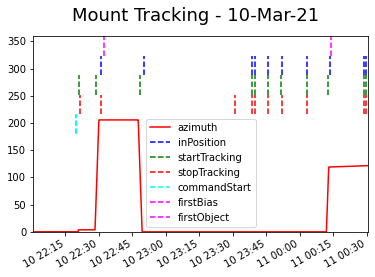

In [48]:
# Plot all of it
startPlot = Time('2021-03-10T22:00:00') #this is UTC
endPlot = Time('2021-03-11T00:30:00')
#startPlot = Time('2021-03-10T22:30:00') #this is UTC
#endPlot = Time('2021-03-10T22:32:00')

fig = plt.figure()
plt.suptitle(f"Mount Tracking - 10-Mar-21", fontsize = 18)
# Azimuth axis
plt.subplot(1,1,1)
ax1 = az['azimuthCalculatedAngle'].plot(color='red', label='azimuth')
ax1.set_ylim(0,360)
for i in range(len(inPosition)):
    t = Time(inPosition.index[i]).tai.isot
    ax1.axvline(t, ymin=0.8, ymax=0.9, color="blue", linestyle="--")
ax1.axvline(t, ymin=0.8, ymax=0.9, color="blue", linestyle="--", label='inPosition')
for i in range(len(startTracking)):
    t = Time(startTracking.index[i]).tai.isot
    ax1.axvline(t, ymin=0.7, ymax=0.8, color="green", linestyle="--")
ax1.axvline(t, ymin=0.7, ymax=0.8, color="green", linestyle="--", label='startTracking')
for i in range(len(stopTracking)):
    t = Time(stopTracking.index[i]).tai.isot
    ax1.axvline(t, ymin=0.6, ymax=0.7, color="red", linestyle="--")
ax1.axvline(t, ymin=0.6, ymax=0.7, color="red", linestyle="--", label='stopTracking')
for i in range(len(commandStart)):
    t = Time(commandStart.index[i]).tai.isot
    ax1.axvline(t, ymin=0.5, ymax=0.6, color="cyan", linestyle="--")
ax1.axvline(t, ymin=0.5, ymax=0.6, color="cyan", linestyle="--", label='commandStart')

firstBias = '2021-03-10T22:31:37' # Got this from the header
t = Time(firstBias).tai.isot
ax1.axvline(t, ymin=0.9, ymax=1.0, color="magenta", linestyle="--", label='firstBias')

firstObject = '2021-03-11T00:13:19' # Got this from the header
t = Time(firstObject).tai.isot
ax1.axvline(t, ymin=0.9, ymax=1.0, color="magenta", linestyle="--", label='firstObject')

ax1.set_xlim(startPlot.tai.isot,endPlot.tai.isot)
ax1.legend()#loc='bottom')
#plt.savefig(f"/home/craiglagegit/DATA/InPosition_Events_10Mar21.pdf")